# Equation solving
The topic of this notebook are algebraic equations and how to solve them. The examples in this notebook follow those from chapter 5 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch05-code-listing.ipynb). 

In [1]:
import numpy as np
import sympy
import scipy
from scipy import linalg as la
import matplotlib as mpl
import matplotlib.pyplot as plt
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


## Linear equations
We start with linear equations of the type
$$\hat{A} x=b$$
where $\hat{A}$ is a $n \times n$ matrix, $x$ is a vector of variables and $b$ is a constant vector. Many systems can be described as linear in physics and other science fields. When a system is not linear it can be linearized around a point. The goal in these problems is to calculate
$$x=\hat{A}^{-1}b$$
In order to solve a system of linear equations of n variables we need n equations. This means that $\hat{A}$ is a square matrix.

We define two linear equations 
$$
    \begin{matrix}
        2x_1 + 3x_2 = 4  \\
        5x_1 + 4x_2 = 3   \\
    \end{matrix}
$$
and compute their values so that we can plot them

In [2]:
x1 = np.linspace(-4, 2, 100)
x2_1 = (4 - 2 * x1)/3
x2_2 = (3 - 5 * x1)/4

We solve the linear system numerically using the [SciPy's linear algebra](https://docs.scipy.org/doc/scipy/reference/linalg.html) module 

In [3]:
from scipy import linalg as la
A = np.array([[2, 3], [5, 4]])
b = np.array([4, 3])
x = la.solve(A, b)
x

array([-1.,  2.])

We plot the two linear equations and the point of intersection that is the (unique) solution of the linear system 

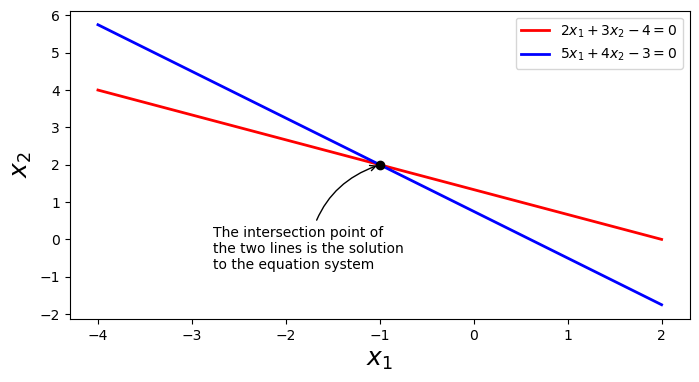

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x1, x2_1, 'r', lw=2, label=r"$2x_1+3x_2-4=0$")
ax.plot(x1, x2_2, 'b', lw=2, label=r"$5x_1+4x_2-3=0$")
ax.plot(x[0], x[1], 'ko', lw=2)
ax.annotate("The intersection point of\nthe two lines is the solution\nto the equation system",
            xy=(x[0], x[1]), xycoords='data',
            xytext=(-120, -75), textcoords='offset points', 
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3, rad=-.3"))

ax.set_xlabel(r"$x_1$", fontsize=18)
ax.set_ylabel(r"$x_2$", fontsize=18)
ax.legend();

We can solve the linear system using symbolic calculations implemented in the [SymPy linear algebra](https://docs.sympy.org/latest/modules/matrices/matrices.html#linear-algebra) module. The algorithm used is [Gaussian elimination] or [LU decomposition](https://en.wikipedia.org/wiki/LU_decomposition). 

In [12]:
A = sympy.Matrix([[2, 3], [5, 4]])
b = sympy.Matrix([4, 3])

In order to have one unique soulution, a system of two equations in two variables must have rank 2

In [13]:
A.rank()

2

### Condition number
One important property of a linear system is its [condition number](https://en.wikipedia.org/wiki/Condition_number). It represents how a little change in the variable $x$ affects the output variable $b$
$$\hat{A} \delta x=\delta b$$
The condition number provides an estimate of the accuracy of the solution. The closer the contion number to 1, the better. 

In [14]:
A.condition_number()

sqrt(2*sqrt(170) + 27)/sqrt(27 - 2*sqrt(170))

In [15]:
x = A.solve(b)
x

Matrix([
[-1],
[ 2]])

## Least squares method
Usually we collect many observations to represent the relationship between one or more independent variables and one dependent variable. These observations are used to find a function that fits the data. One such function can be defined using polynomials.
$$y=a_0 + a_1 x + a_2 x^2+...+a_n x^n$$
This equation is linear in the parameters $a_i$ that are unknown and can be found using the least squares methods. For instance we create some noisy data points around a polynomial function. We use the least squares method to fit the data points so that we will be able to compare the found parameters with the true ones. 

In [2]:
np.random.seed(1234)

# define true model parameters
x = np.linspace(-1, 1, 100)
a, b, c = 1, 2, 3
y_exact = a + b * x + c * x**2

# simulate noisy (X,Y) data points
m = 100
X = 1 - 2 * np.random.rand(m)
Y = a + b * X + c * X**2 + np.random.randn(m)

We build a $m \times 3$ matrix of $X^0, X^1,X^2$ values. Each triple represents an instance of the linear equation 
$$y=a_0x^0 + a_1 x^1 + a_2 x^2$$
With this approach we can use the lstq() method of the SciPy linear algebra module to solve the **overdetermined** problem to calculate the three unknown parameters $a_i$. We fit two models: one with polynomials up to the 2nd degree and another one up to the 15th degree. The parameters value are determined by minimizing the squared difference between the data and the model using the [lstq()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html) method. 

In [11]:
# fit the data to the model using linear least square
A = np.vstack([X**0, X**1, X**2])  # see np.vander for alternative
sol, r, rank, sv = la.lstsq(A.T, Y)
y_fit2 = sol[0] + sol[1] * x + sol[2] * x**2

The data points are represented as a rectangular matrix by stacking the value of the polynomial terms

In [12]:
A.shape

(3, 100)

In [15]:
A = np.vstack([X**n for n in range(16)])
sol, r, rank, sv = la.lstsq(A.T, Y)
y_fit15 = sum([s * x**n for n, s in enumerate(sol)])
A.shape

(16, 100)

As we can see from the plot, the 15 degree polynomial overfits the data, while the 2nd degrees looks able to fit the main pattern of the data.

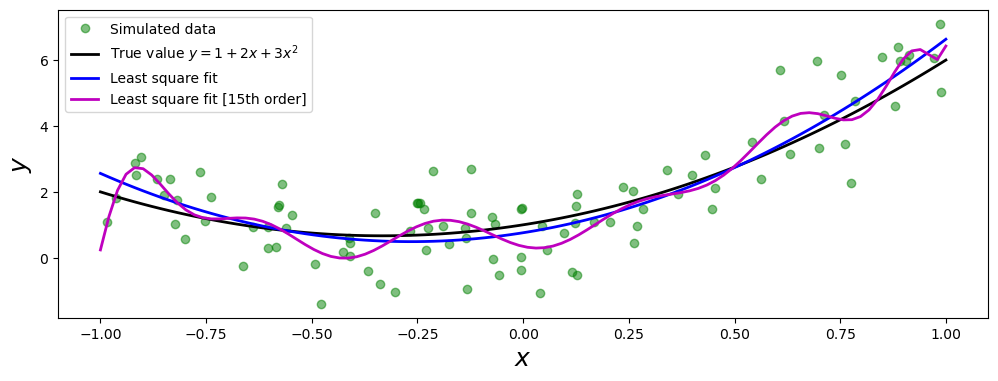

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(X, Y, 'go', alpha=0.5, label='Simulated data')
ax.plot(x, y_exact, 'k', lw=2, label='True value $y = 1 + 2x + 3x^2$')
ax.plot(x, y_fit2, 'b', lw=2, label='Least square fit')
ax.plot(x, y_fit15, 'm', lw=2, label='Least square fit [15th order]')
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$y$", fontsize=18)
ax.legend(loc=2);

## Eigenvalue problems
In many applications it may be useful to change or reduce the number independent variables. The first case is when the reference system is changed because the problem has a particular simmetry that makes it easier to be rrepresented using a different coordinates system. The 2nd case is when we want to select a subset of the variables that have most of the information such as in principal component analysis. We start from a linear system and we want to find its eigenvalues $\lambda$
$$\hat{A}x=\lambda x$$
This equation can be also written in the form
$$(\hat{A}-\lambda \hat{I})x = 0$$
In order to have a solution for all $x$, the determinant must be zero
$$|\hat{A}-\lambda \hat{I}|=0$$
If the rank of the matrix $\hat{A}$ is N, we have to solve an algebraic equation of degree N in $\lambda$. If the matrix $\hat{A}$ is [hermitian](https://en.wikipedia.org/wiki/Hermitian_matrix#Diagonalizable) or symmetric and real, its eigenvalues are real. The correlation matrix is a well known example of a symmetric matrix. The [ScyPy linear algebra module]() provides a method to compute the eigenvalues and the corresponding eigenvectors of a square matrix. 

In [21]:
A = np.array([[1, 3, 5], [3, 5, 3], [5, 3, 9]])
A

array([[1, 3, 5],
       [3, 5, 3],
       [5, 3, 9]])

In [22]:
evals, evecs = la.eigh(A)
evals

array([-1.75902942,  3.40592034, 13.35310908])

When the matrix $\hat{A}$ is not hermitian the solutions of the algebraic equation are represented as complex numbers with the imaginary part that can be not zero. 

## Nonlinear equations
The roots of an univariate nonlinear equation $f(x)=0$ can be found numerically using different algorithms. The simplest one is the [bisection method](https://en.wikipedia.org/wiki/Bisection_method) and another is the [**Newton method**](https://en.wikipedia.org/wiki/Newton%27s_method) that involves computing the inverse of the first derivative. The [SciPy optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding) module provides multiple functions for numerical root finding. We can define a function in three ways. One way is creating a named function, e.g. $f$ and then passing to the plot() method an array with the values of the independent variable $x$ and the function definition. The second way is to create an unamed (lambda) function and passing to the plot() method the $x$ array and the function with its argument $f(x)$. The third way is to define a function that returns the correspnding value for each instance of its argument.

In [35]:
a = -2.0
b = 2.0
x = np.linspace(a, b, 1000)
#f = x**3 - 3 * np.sin(x)
#f = lambda x: x**3 - 3 * np.sin(x)
def f(x):
    return x**3 - 3 * np.sin(x)

Text(0.5, 1.0, '$f(x)=x^3-3 sin(x)$')

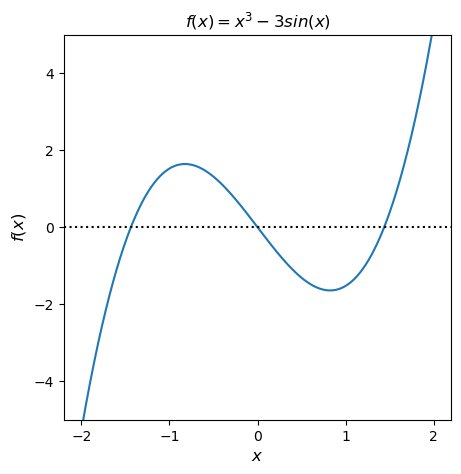

In [36]:
fig, ax = plt.subplots(figsize=(5.0, 5.0), sharey=True)
#ax.plot(x, f, lw=1.5)
ax.plot(x, f(x), lw=1.5)
ax.axhline(0, ls=':', color='k')
ax.set_ylim(-5, 5)
ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.set_title('$f(x)=x^3-3 sin(x)$')

The [bisect()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.bisect.html#bisect) method needs two points a and b where the function has different sign, if f(a) > 0, then f(b) < 0 and viceversa

In [43]:
from scipy import optimize
root_1 = optimize.bisect(f, a, -1)
root_1

-1.4380046297828812

In [44]:
root_2 = optimize.bisect(f, -1, 1)
root_2

0.0

In [45]:
root_3 = optimize.bisect(f, 1, b)
root_3

1.4380046297828812

The newton() method uses an initial guess point $x_0$ to start the search process

In [55]:
optimize.newton(lambda x: x**3 - 3 * np.sin(x), x0 = a)

-1.4380046297835347

In [57]:
optimize.newton(lambda x: x**3 - 3 * np.sin(x), x0 = 0)

0.0

In [58]:
optimize.newton(lambda x: x**3 - 3 * np.sin(x), x0 = b)

1.4380046297835347

## System of multivariate nonlinear equations
Solving a system of nonlinear equations means finding the points in space where they intersect. Algebraic methods that use symbols manipulation are by substitution and by elimination. Numerical methods are similar to those used for finding the roots of a univariate function. The Newton method for multivariate nonlinear equations involves the computation of inverse of the Jacobian, that is the partial derivatives of the equations. As an intuition, each equation represents a surface. The Jacobian represents the gradient of each surface at any point in space. As an example, we look for the solutions of the nonlinear system
\begin{matrix}
    y - x^3 - 2x^2 + 1 = 0 \\
    y + x^2 - 1 = 0 \\
\end{matrix}


For simple systems of nonlinear equations, like in the example, SymPy provides [solvers](https://docs.sympy.org/latest/tutorials/intro-tutorial/solvers.html) to solve the equations symbolically

In [6]:
x, y = sympy.symbols('x, y')
vars = [x, y]
f1 = y - x**3 - 2 * x**2 + 1
f2 = y + x**2 - 1
system = [f1, f2]
sympy.nonlinsolve(system, vars)

{(-1, 0), (-1 + sqrt(3), -3 + 2*sqrt(3)), (-sqrt(3) - 1, -2*sqrt(3) - 3)}

However often the system cannot be solved analytically and numerical methods must be used

In [7]:
def f(x):
    return [x[1] - x[0]**3 - 2 * x[0]**2 + 1, x[1] + x[0]**2 - 1]

As for the Newton method for the univariate equation, the solution depends on the initial guess $(x_i,y_i)$

In [75]:
x_0 = -3.0
y_0 = -5.0
s_0 = optimize.fsolve(f, [x_0, y_0])

In [76]:
x_1 = -1.0
y_1 = -1.0
s_1 = optimize.fsolve(f, [x_1, y_1])

In [77]:
x_2 = 1.0
y_2 = 1.0
s_2 = optimize.fsolve(f, [x_2, y_2])

In [64]:
x = np.linspace(-3, 2, 5000)
y1 = x**3 + 2 * x**2 -1
y2 = -x**2 + 1

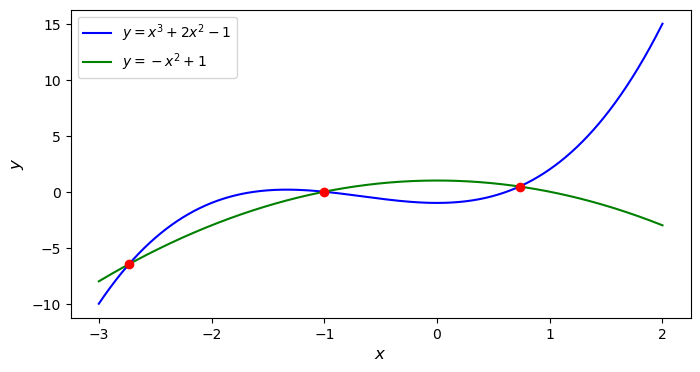

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y1, 'b', lw=1.5, label=r'$y = x^3 + 2x^2 - 1$')
ax.plot(x, y2, 'g', lw=1.5, label=r'$y = -x^2 + 1$')
ax.plot(s_0[0], s_0[1], 'ro')
ax.plot(s_1[0], s_1[1], 'ro')
ax.plot(s_2[0], s_2[1], 'ro')
ax.legend(loc=0)
ax.set_xlabel(r'$x$', fontsize=12)
ax.set_ylabel(r'$y$', fontsize=12);